(-0.5, 639.5, 479.5, -0.5)

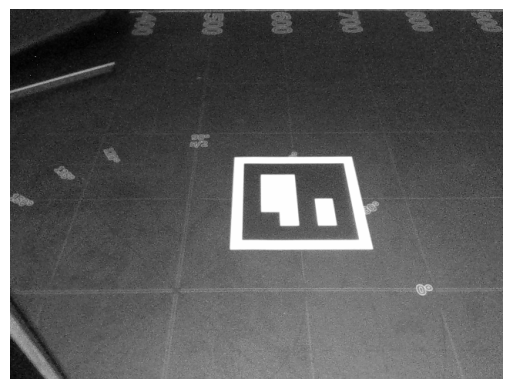

In [ ]:
# load image using opencv
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load an image using OpenCV
image = cv2.imread('../ressources/img2.png')

# Convert the image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display the grayscale image using matplotlib
plt.imshow(gray_image, cmap='gray')
plt.axis('off')  # Hide the axis

In [ ]:
aruco_dictionary = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
aruco_parameters =  cv2.aruco.DetectorParameters()
aruco_detector = cv2.aruco.ArucoDetector(aruco_dictionary, aruco_parameters)

markerCorners, markerIds, _ = aruco_detector.detectMarkers(image)

print(markerCorners)
print(markerIds)

(array([[[304., 200.],
        [432., 200.],
        [452., 298.],
        [302., 299.]]], dtype=float32),)
[[22]]


In [ ]:
cameraMatrix = np.array([
    [610.3757934570312, 0, 318.8870544433594],
    [0, 609.22705078125, 246.54132080078125],
    [0, 0, 1]
    ])
distCoeffs = np.array([0, 0, 0, 0, 0])

rvec, tvec, markerPoints = cv2.aruco.estimatePoseSingleMarkers(markerCorners, 0.1, cameraMatrix=cameraMatrix, distCoeffs=distCoeffs)

print(rvec)
print(tvec)

[[[ 2.36229772e+00 -5.10163881e-03  3.95767896e-04]]]
[[[ 0.03856262 -0.0008765   0.44189552]]]


(-0.5, 639.5, 479.5, -0.5)

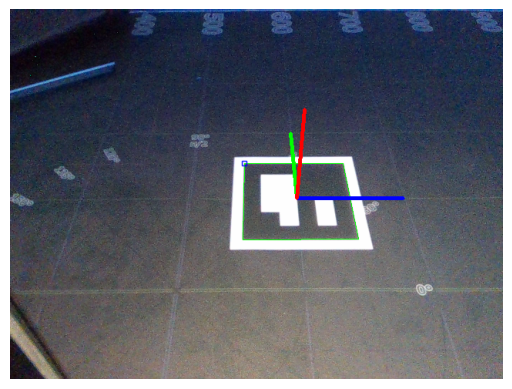

In [ ]:
cv2.aruco.drawDetectedMarkers(image, markerCorners)
cv2.drawFrameAxes(image, cameraMatrix, distCoeffs, rvec, tvec, 0.1) 

plt.imshow(image, cmap='gray')
plt.axis('off')  # Hide the axis

# T robot to aruco 0.4m

In [ ]:
# convert rvec to ROS coodinates
rvec_ros = np.array([rvec[0][0][1]-np.pi/2, rvec[0][0][0], rvec[0][0][2]])

print(rvec_ros) 
# ros2 run tf2_ros static_transform_publisher 0.03856262 -0.0008765   0.44189552  -1.57589797e+00  2.36229772e+00  3.95767896e-04 camera_color_optical_frame aruco_cam
# ros2 run tf2_ros static_transform_publisher 0.4 0 0 3.14159 0 0 aruco_cam base_link2
# ros2 run tf2_ros tf2_echo base_link2 camera_link

[-1.57589797e+00  2.36229772e+00  3.95767896e-04]
